In [21]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import sys
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision.transforms import Normalize
from torchvision.transforms import ToTensor
import os

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.3
pandas 3.0.1
sklearn 1.8.0
torch 2.10.0+cu128
cuda:0


# 加载数据

In [22]:
train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

#计算均值和方差
def cal_mean_std(ds):
    mean = 0.
    std = 0.
    for image_input, _ in ds:
        # 遍历每张图片, image.shape=[1,28,28]
        mean += image_input.mean(dim=(1, 2))
        # 计算每张图片的均值, dim=(1, 2)表示每张图片的宽高共同求均值
        std += image_input.std(dim=(1, 2))
    mean /= len(ds)
    std /= len(ds)
    return mean, std
    # 单通道的图, mean结果是0维张量 
    # 如果是多通道的图, mean是1维张量, 传入Normalize时最好使用tolist


mean_train, std_train = cal_mean_std(train_ds)
transforms=nn.Sequential(Normalize(mean_train, std_train))

In [23]:
import random


def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)

In [24]:
# 数据加载器, 将其进行分批和其他处理
train_ld = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)  
#batch_size批大小, shuffle洗牌, 这是为了避免局部最优解
val_ld = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)
# 验证集不需要打乱

## 定义模型

在SELU中加入AlphaDropout

Dropout是指在训练过程中随机丢弃一些神经元(置为0)  
1. 有效缓解过拟合
2. 引入随机性, 提高泛化能力
但是:
3. 会引入噪声, 影响收敛速度
4. 在小模型或者小数据集中, 或使用了BatchNorm时, 表现可能会变差

AlphaDropout 是专门为 SELU 激活函数设计的 Dropout 变体, 用于保持输入的均值和方差不变(自归一化特性)  
相比普通的Dropout, AlphaDropout会在将一些神经元置为0的同时, 改变另外神经元的权重(乘以α), 这个α是根据SELU公式设计的常数. 使得输出均值仍为0, 输出方差仍为1.  
必须满足:
1. 激活函数使用SELU
2. 权重初始化使用LeCun Normal

In [25]:
import math
class NeuralNetwork(nn.Module):
    def __init__(self, layers_num=2):
        super().__init__()
        self.transforms = transforms 
        # 预处理层，标准化
        self.flatten = nn.Flatten()
        self.linear_selu_stack = nn.Sequential(
            nn.Linear(28 * 28, 100),
            nn.SELU(),
            nn.AlphaDropout(p=0.05)
            # 增加dropout, p=0.1表示以0.1的概率将某些神经元置0, 防止过拟合
        )
        # 添加第一层
        for i in range(1, layers_num):
            self.linear_selu_stack.add_module(f"Linear_{i}", nn.Linear(100, 100))
            self.linear_selu_stack.add_module(f"SELU_{i}", nn.SELU())
            # 加上layer_num个全连接层和激活函数
            self.linear_selu_stack.add_module(f"dropout_{i}", nn.AlphaDropout(p=0.05))
            # 其他激活函数可以只在前几层添加dropout, 但使用SELU+AlphaDropout, 必须要在全层添加.
            # 直观解释是, 在前面的层做Dropout, 是让模型学会更通用的特征; 在后层加, 是在删除做决策的依据. 层数太多是一直在随机破坏信息.
            # 使用SELU时, 更推荐各层都做小规模AlphaDropout, 以保持自归一化
        self.linear_selu_stack.add_module("Output Layer", nn.Linear(100, 10))
        # 添加输出层
        
        self.init_weights()
        # 初始化权重
        
    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                fan_in = m.weight.size(1)
                std = math.sqrt(1.0 / fan_in) 
                nn.init.normal_(m.weight, mean=0.0, std=std)
                # 使用LeCun标准化(均值为0, 方差为1/sqrt(fan_in))
                nn.init.zeros_(m.bias)
                
    def forward(self, x):
        x = self.transforms(x) 
        # 标准化
        # x.shape [batch size, 1, 28, 28]
        x = self.flatten(x)  
        # flattened x.shape [batch size, 28 * 28]
        logits = self.linear_selu_stack(x)
        # logits.shape [batch size, 10]
        return logits
total=0
# 设置层数为20层, 计算总参数量
for idx, (key, value) in enumerate(NeuralNetwork(20).named_parameters()):
    # named_parameters()返回一个迭代器, 里面的每一项是(参数名, 参数)
    # enumerate()同时得到索引和元素
    total+=np.prod(value.shape)
    # value是一个tensor, prod将ndarray里的每个元素相乘(product)
    # 累加起来得到总参数量
total 

np.int64(271410)

In [26]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute 
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience 
        # 多少个step没有提升min_delta就停止训练
        self.min_delta = min_delta 
        # 最小的提升幅度
        self.best_metric = -1
        self.counter = 0 
        # 计数器, 记录多少个step没有提升
        
    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            self.best_metric = metric
            # 将当前算子作为最佳算子
            self.counter = 0
        else: 
            self.counter += 1
            # 假如这一步没有更优, 则计数器加一
            
    @property 
    # property装饰器指将方法变成属性
    def early_stop(self):
        return self.counter >= self.patience

In [27]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_epoch=1, save_step=500, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch. 
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir # 保存路径
        self.save_step = save_step # 保存步数
        self.save_best_only = save_best_only # 是否只保存最好的模型
        self.best_metrics = -1 # 最好的指标, 指标不可能为负数, 所以初始化为-1
        self.save_epoch = save_epoch
        # mkdir
        if not os.path.exists(self.save_dir): 
            # 如果不存在保存路径, 则创建
            os.mkdir(self.save_dir)
        
    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0: 
            # 每隔save_step步保存一次
            return
        
        if self.save_best_only:
            assert metric is not None,'metric is not None' 
            # 必须传入metric
            if metric >= self.best_metrics:
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "best_dnn_selu_dropout.ckpt")) 
                # os.path.join表示路径拼接, 相当于save_dir+"best.ckpt"
                # 保存最好的模型, 覆盖之前的模型
                # 不保存step, 只保存state_dict, 即模型参数, 不保存优化器参数
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt")) 
            # 保存每个step的模型, 不覆盖之前的模型
            # 保存step, 保存state_dict, 即模型参数, 不保存优化器参数

In [28]:
network = NeuralNetwork(10)
network.to(device)
# 1. 定义损失函数
loss_fct = nn.CrossEntropyLoss()
# 输出时将logits经过softmax, 和转换为one-hot编码的标签值计算交叉熵损失
# 得到的是标量(0维张量)

# 2. 定义优化器 采用SGD(随机梯度下降, stochastic gradient descent)
opt = torch.optim.SGD(network.parameters(), lr=0.001, momentum=0.9)
# lr学习率, momentum动量

In [29]:
for name, param in network.named_parameters(): 
    # 打印模型参数
    print(name)
    print(param.shape)

linear_selu_stack.0.weight
torch.Size([100, 784])
linear_selu_stack.0.bias
torch.Size([100])
linear_selu_stack.Linear_1.weight
torch.Size([100, 100])
linear_selu_stack.Linear_1.bias
torch.Size([100])
linear_selu_stack.Linear_2.weight
torch.Size([100, 100])
linear_selu_stack.Linear_2.bias
torch.Size([100])
linear_selu_stack.Linear_3.weight
torch.Size([100, 100])
linear_selu_stack.Linear_3.bias
torch.Size([100])
linear_selu_stack.Linear_4.weight
torch.Size([100, 100])
linear_selu_stack.Linear_4.bias
torch.Size([100])
linear_selu_stack.Linear_5.weight
torch.Size([100, 100])
linear_selu_stack.Linear_5.bias
torch.Size([100])
linear_selu_stack.Linear_6.weight
torch.Size([100, 100])
linear_selu_stack.Linear_6.bias
torch.Size([100])
linear_selu_stack.Linear_7.weight
torch.Size([100, 100])
linear_selu_stack.Linear_7.bias
torch.Size([100])
linear_selu_stack.Linear_8.weight
torch.Size([100, 100])
linear_selu_stack.Linear_8.bias
torch.Size([100])
linear_selu_stack.Linear_9.weight
torch.Size([100, 

In [30]:
from sklearn.metrics import accuracy_score


# 3.编写评估函数
@torch.no_grad()
# 装饰器, 禁止反向传播, 节省内存
def evaluating(model, dataloader, loss_function):
    loss_list = []
    # 记录损失
    pred_list = []
    # 记录预测
    label_list = []
    # 记录标签
    for data, label in dataloader:
        # 一共10000/32=312个batch
        data = data.to(device)
        # 把tensor放入GPU
        label = label.to(device)
        # 转到GPU
        logits = model(data)
        # 前向计算
        loss = loss_function(logits, label)
        # 使用loss_function计算本batch的损失, 得到的实际上是一个张量
        loss_list.append(loss.item())
        # 记录损失, item把tensor转换为数值, 注意item只能处理0维张量  

        pred = logits.argmax(axis=-1)
        # 验证集预测, argmax返回最大值索引数组
        # logits是一个(32, 10)数组, 求出的pred是一个(32, )数组,
        # 即每个样本使用十个标签概率的最大值的索引作为预测值
        pred_list.extend(pred.cpu().numpy().tolist())
        # numpy()将PyTorch张量转换为NumPy数组。只有当张量在CPU上时, 这个转换才是合法的
        label_list.extend(label.cpu().numpy().tolist())

    acc = accuracy_score(label_list, pred_list)
    # 计算准确率
    return np.mean(loss_list), acc

In [31]:
save_ckpt_callback = SaveCheckpointsCallback("checkpoints", save_best_only=True)
early_stop_callback = EarlyStopCallback(patience=5)

In [32]:
# 4.训练

def training(model, train_loader, val_loader, epoch, loss_function,
             optimizer,
             tensorboard=None,
             save_ckpt=None,
             early_stop=None,
             eval_step=500):
    """
    训练函数
    :param model: 模型
    :param train_loader: 训练数据集
    :param val_loader: 验证数据集
    :param epoch: 训练轮数
    :param loss_function: 损失函数
    :param optimizer: 优化器
    :param tensorboard: 可视化回调函数
    :param save_ckpt: 保存回调函数
    :param early_stop: 早停回调函数
    :param eval_step: 每训练多少batch对验证集进行评估
    :return: dict
    """
    record_dict = {
        "train": [],
        "val": []
    }
    # 存储训练集和测试集的损失和准确率
    global_step = 0
    # 记录总步数, 在进度条中使用
    model.train()
    # 进入训练模式
    # 对于一些特定层很重要：
    # Dropout → 在训练阶段才会随机丢弃神经元
    # BatchNorm → 使用 batch 的均值和方差
    with (tqdm(total=epoch * len(train_loader)) as pbar): 
        # with是上下文管理器, 保证进度条结束后自动关闭
        # 进度条一共 len(train_loader)*epoch 步
        for epoch_id in range(epoch): 
            # 训练epoch次
            for data, label in train_loader: 
                # 每次迭代得到一个batch
                # 执行次数是60000/32=1875
                data = data.to(device) 
                # datas尺寸是[batch_size,1,28,28], 转到GPU
                label = label.to(device) 
                # labels尺寸是[batch_size], 转到GPU
                optimizer.zero_grad()
                # 梯度清空, PyTorch会累加梯度, 要避免上一batch的梯度影响后面
                logits = model(data)
                # 正向计算, 得到未经过softmax的输出
                loss = loss_function(logits, label)
                # 计算损失
                loss.backward()
                # 梯度回传, loss.backward()会计算梯度, loss对模型参数(权重和偏置)求导
                optimizer.step()
                # 调整优化器, 改变学习率(如果使用了学习率调度器), 更新模型参数和一些其他值
                # 梯度计算并存储在模型参数的 .grad 属性中
                # 优化器使用这些存储的梯度来更新模型参数

                pred = logits.argmax(axis=-1) 
                # 对训练集预测
                acc = accuracy_score(label.cpu().numpy(), pred.cpu().numpy()) 
                # 每个batch计算准确率
                loss = loss.cpu().item()
                # loss这一0维张量转换为数值
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                }) 
                # 记录训练集信息, 每一步的损失, 准确率, 步数
                
                if global_step % eval_step == 0:
                    model.eval() 
                    # 进入评估模式
                    # Dropout 停用
                    # BatchNorm 使用训练时统计值
                    val_loss, val_acc = evaluating(model, val_loader, 
                                                   loss_function)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train() 
                    # 进入训练模式
                    
                    # 1. 使用tensorboard可视化
                    if tensorboard is not None:
                        tensorboard(
                            global_step, 
                            loss=loss, val_loss=val_loss,
                            acc=acc, val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"], # 取出当前学习率
                            )
                    
                    # 2. 保存模型权重save model checkpoint
                    if save_ckpt is not None:
                        save_ckpt(global_step, model.state_dict(), metric=val_acc) 
                        # 保存最好的模型, 覆盖之前的模型
                        # 保存step, 保存state_dict,通过metric判断是否保存最好的模型

                    # 3. 早停Early Stop
                    if early_stop is not None:
                        early_stop(val_acc) 
                        # 验证集准确率不再提升, 则停止训练
                        if early_stop.early_stop:
                            # 注意之前有property装饰器, 将方法作为属性计算
                            # 属性的值就是方法的返回值
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                global_step += 1 
                # 全局步数加1
                pbar.update(1) 
                # 更新进度条
                pbar.set_postfix({"epoch": epoch_id}) 
                # 设置进度条显示信息
        
    return record_dict

In [33]:
record=training(network, train_ld, val_ld, epoch=100, loss_function=loss_fct, optimizer=opt, tensorboard=None, save_ckpt=save_ckpt_callback, early_stop=early_stop_callback, eval_step=1000)

  0%|          | 0/187500 [00:00<?, ?it/s]

Early stop at epoch 10 / global_step 19000


In [34]:
print(pd.DataFrame(record["train"]).set_index("step")[-50:])

           loss      acc
step                    
18951  0.405683  0.87500
18952  0.466635  0.81250
18953  0.355584  0.90625
18954  0.579858  0.81250
18955  0.079763  1.00000
18956  0.420522  0.87500
18957  0.426435  0.87500
18958  0.254742  0.90625
18959  0.733179  0.78125
18960  0.371508  0.90625
18961  0.400163  0.93750
18962  0.152417  0.93750
18963  0.564444  0.87500
18964  0.272417  0.84375
18965  0.360564  0.84375
18966  0.136514  1.00000
18967  0.213949  0.93750
18968  0.327262  0.93750
18969  0.328968  0.87500
18970  0.203205  0.90625
18971  0.344384  0.84375
18972  0.376137  0.81250
18973  0.424365  0.87500
18974  0.539783  0.78125
18975  0.419826  0.84375
18976  0.232939  0.93750
18977  0.313527  0.84375
18978  0.650826  0.81250
18979  0.377739  0.90625
18980  0.447299  0.78125
18981  0.343771  0.93750
18982  0.366701  0.90625
18983  0.426711  0.81250
18984  0.834523  0.71875
18985  0.316449  0.93750
18986  0.339538  0.84375
18987  0.292751  0.81250
18988  0.477241  0.81250


加上Dropout效果变差, 可能是因为任务太小; 过拟合不明显

Index(['loss', 'acc'], dtype='str')
step
0        0.09375
500      0.75000
1000     0.81250
1500     0.78125
2000     0.75000
2500     0.84375
3000     0.93750
3500     0.93750
4000     0.87500
4500     0.65625
5000     0.75000
5500     0.93750
6000     0.90625
6500     0.93750
7000     0.75000
7500     0.84375
8000     0.96875
8500     0.87500
9000     0.90625
9500     0.78125
10000    0.84375
10500    0.78125
11000    0.81250
11500    0.90625
12000    0.84375
12500    0.90625
13000    0.90625
13500    0.93750
14000    0.84375
14500    0.78125
15000    0.90625
15500    0.84375
16000    0.84375
16500    0.84375
17000    0.84375
17500    0.81250
18000    0.93750
18500    0.84375
19000    0.75000
Name: acc, dtype: float64
step
0        0.053533
1000     0.803350
2000     0.833683
3000     0.842917
4000     0.844950
5000     0.848800
6000     0.859117
7000     0.862650
8000     0.866000
9000     0.871967
10000    0.874150
11000    0.876450
12000    0.877683
13000    0.877217
14000    0.88

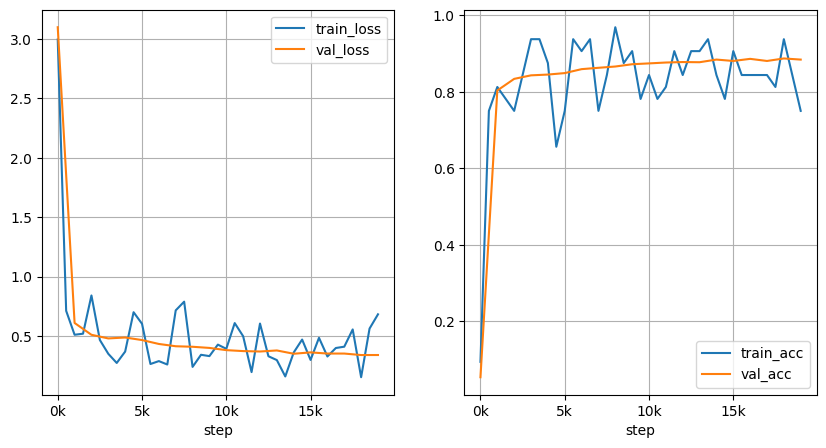

In [35]:
def plot_learning_curves(record_dict, sample_step=500):
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    # set_index将行索引设置成step, 每隔sample_step取一次
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")
    last_step = train_df.index[-1]
    # 最后一步的步数
    print(train_df.columns)
    print(train_df['acc'])
    print(val_df['acc'])
    
    fig_num = len(train_df.columns)
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for index, item in enumerate(train_df.columns):
        # enumerate同时得到索引和值
        # index = 0, 1, item = 'loss', 'acc'
        # print(train_df[item].values)
        axs[index].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[index].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[index].grid()
        axs[index].legend()
        axs[index].set_xticks(range(0, train_df.index[-1], 5000)) 
        axs[index].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, last_step, 5000)))
        axs[index].set_xlabel("step")
    
    plt.show()

plot_learning_curves(record)